# Experiment: Agentic Real-Time Metadata Standardization

## Configurations

Run this notebook from the repository root, which is where it lives — every path below is relative to it.

Before running it, create a `.env` file in the project root with the following API keys:

```
OPENAI_API_KEY=your-openai-api-key          # Required — for LLM calls
CEDAR_API_KEY=your-cedar-api-key            # Required — for fetching CEDAR templates
BIOPORTAL_API_KEY=your-bioportal-api-key    # Required — for ontology term lookups

LANGFUSE_PUBLIC_KEY=pk-lf-your-public-key   # Optional — enables observability for LLM calls and agent runs
LANGFUSE_SECRET_KEY=sk-lf-your-secret-key   # Optional — tracing is on only when both keys are set
LANGFUSE_HOST=https://cloud.langfuse.com    # Optional — use https://us.cloud.langfuse.com for US cloud
```

See [.env.example](.env.example) for a template.

In [2]:
import sys
from pathlib import Path

EVALUATION_DIR = Path.cwd() / "evaluation"
if str(EVALUATION_DIR) not in sys.path:
    sys.path.insert(0, str(EVALUATION_DIR))

`DATA_ROOT` points to the root data directory. The evaluation functions expect the following directory structure underneath it:

```
DATA_ROOT/
├── schemas/
│   ├── atacseq.json              # JSON Schema for each assay type
│   ├── lcms.json
│   └── ...
├── atacseq/                      # One directory per assay type
│   ├── input/
│   │   ├── atacseq-<hash>.json   # Legacy metadata records (input)
│   │   └── ...
│   ├── gold/
│   │   ├── atacseq-<hash>.json   # Gold-standard reference outputs
│   │   └── ...
│   └── output/
│       └── <MODEL>/              # e.g., "gpt-5.6-terra"
│           ├── baseline/
│           │   ├── atacseq-<hash>.json   # Prompt-only LLM outputs
│           │   └── ...
│           └── arms-agent/
│               ├── atacseq-<hash>.json   # Tool-augmented agent outputs
│               └── ...
└── ...
```

Gold-standard and output files share the same filenames so that each output can be matched to its reference for evaluation.

The leaf directory is the run's name, and it is the same name the CLI takes: `python -m evaluation --condition baseline` writes to the matching directory under `--output`, so a run made from the command line and one made from this notebook land in the same place.

In [1]:
DATA_ROOT = "data"

`MODEL` specifies which LLM model was used for the migration run.

In [3]:
MODEL = "gpt-5.6-terra"

`ASSAYS` and `RUN_TYPES` select what the sweep covers: every assay in `ASSAYS` is run through every condition in `RUN_TYPES`, so the sweep is the product of the two. Trim either list to run a subset.

`RUN_TYPES` takes the same values as the CLI's `--condition` flag, and each names the directory its predictions are written to:

| `RUN_TYPES` entry | CLI equivalent |
|---|---|
| `baseline` | `--condition baseline` — field and vocabulary names only |
| `arms-agent` | `--condition arms-agent` — the tool-augmented agent |

The rows are the conditions declared under `evaluation/conditions/`: dropping a module in there adds one, and `RUN_TYPES` may name it at once. A name outside that set raises before anything runs.

In [4]:
# Every assay the sweep covers, in the order it runs them.  Trim the list to run a
# subset -- ["atacseq"] to validate one assay before spending on the rest.
ASSAYS = [
    "atacseq",
    "rnaseq",
    "af",
    "celldive",
    "codex",
    "histology",
    "imc-2d",
    "lightsheet",
    "mibi",
    "desi",
    "lcms",
    "maldi",
]

# Every condition each of those assays is run through.
RUN_TYPES = ["baseline", "arms-agent"]

## Run Experiments

Two calls: `plan_sweep` says what the sweep covers and checks that it can run, `run_sweep` runs it. Nothing is spent until `RUN_EXPERIMENT` is `True`.

Every assay in `ASSAYS` goes through every condition in `RUN_TYPES` — one assay at a time, all of its conditions before the next assay starts, so stopping early leaves whole assays comparable across conditions. Each run reads `DATA_ROOT/<assay>/input` and writes to `DATA_ROOT/<assay>/output/<MODEL>/<RUN_TYPE>`, which is the layout the analysis section reads back.

Both calls live in [evaluation/sweep.py](evaluation/sweep.py), which is also where a run gets its condition, its API keys and its traces: each assay's traces are filed under a tracing environment of its own, named `experiment-<assay>`, so a sweep can be read one assay at a time in the Langfuse UI, with the condition riding along as a trace tag.

In [5]:
RUN_EXPERIMENT = False  # Change to "True" to run the experiment. Be careful it costs money to run it!

### The plan

`plan_sweep` reads the API keys from `.env`, then raises on anything that would otherwise fail partway through a sweep: an unknown assay, an unknown condition, an assay with no input records, or a key the chosen conditions need and the environment does not have. A bad name should cost nothing.

What it prints is what the next cell will run.

In [6]:
from sweep import plan_sweep, run_sweep

plan = plan_sweep(DATA_ROOT, MODEL, assays=ASSAYS, run_types=RUN_TYPES)

Sweep: 12 assay(s) x 2 condition(s) = 24 run(s), 1678 record migration(s) in total.
  model      gpt-5.6-terra
  assays     atacseq, rnaseq, af, celldive, codex, histology, imc-2d, lightsheet, mibi, desi, lcms, maldi
  conditions baseline, arms-agent
  writing to data/<assay>/output/gpt-5.6-terra/<condition>/


### The sweep

The only cell that spends money, and only when `RUN_EXPERIMENT` is `True`. While it is `False` the call lists the runs it would make, one line each, and stops.

Each run is handed to a worker thread, because `run_experiment` drives its per-file concurrency with `asyncio.run` and needs a thread of its own to own the loop. The sweep adds no parallelism of its own: it waits for each run to finish before starting the next.

In [7]:
run_sweep(plan, dry_run=not RUN_EXPERIMENT)

would run  [1/24] atacseq | baseline | 100 record(s) -> data/atacseq/output/gpt-5.6-terra/baseline
would run  [2/24] atacseq | arms-agent | 100 record(s) -> data/atacseq/output/gpt-5.6-terra/arms-agent
would run  [3/24] rnaseq | baseline | 100 record(s) -> data/rnaseq/output/gpt-5.6-terra/baseline
would run  [4/24] rnaseq | arms-agent | 100 record(s) -> data/rnaseq/output/gpt-5.6-terra/arms-agent
would run  [5/24] af | baseline | 100 record(s) -> data/af/output/gpt-5.6-terra/baseline
would run  [6/24] af | arms-agent | 100 record(s) -> data/af/output/gpt-5.6-terra/arms-agent
would run  [7/24] celldive | baseline | 32 record(s) -> data/celldive/output/gpt-5.6-terra/baseline
would run  [8/24] celldive | arms-agent | 32 record(s) -> data/celldive/output/gpt-5.6-terra/arms-agent
would run  [9/24] codex | baseline | 100 record(s) -> data/codex/output/gpt-5.6-terra/baseline
would run  [10/24] codex | arms-agent | 100 record(s) -> data/codex/output/gpt-5.6-terra/arms-agent
would run  [11/24] 

## Data Analysis

Scoring reads only files already on disk — no API keys, no LLM calls — so this section can be re-run freely.

In [8]:
import pandas as pd

import notebook_utils
from analysis.significance import (
    build_per_assay_precision_recall_table,
    build_precision_recall_table,
)

# The two conditions compared: the baseline to beat, and the system challenging it.
# Every difference is SYSTEM_RUN minus BASELINE_RUN, so a positive number favours the system.
BASELINE_RUN = "baseline"
SYSTEM_RUN = "arms-agent"

### Precision and recall

Two numbers, reported for every assay and every kind of field.

- **Precision** — of the values a method filled in, how many were right. Low precision means it makes things up.
- **Recall** — of the values the gold standard asks for, how many the method produced. Low recall means it leaves things out.

Blank fields earn no credit either way. Agreeing that a field should be empty is not counted, so a method cannot score well by filling in nothing.

**The field types.** `ontology` fields are the ones the CEDAR template ties to a controlled vocabulary, so the method has to come back with a term from the right ontology — the hard part of the job. `non_ontology` is everything else: free text, numbers, identifiers. `all` is both together.

### Two units of analysis

The corpus repeats corrections: the same field with the same gold value recurs across many records. One systematic fix can therefore be counted a hundred times. So the same predictions are scored twice, under two different ideas of what counts as one unit.

| unit | one unit is | what it answers | table |
| --- | --- | --- | --- |
| **Instance-weighted** | one field of one record | how much work a curator is spared | **Table 1**, below |
| **Deduplicated** | one distinct value | how wide a range of values a method handles | **Table 2**, next section |

The two can disagree, and the gap is informative. A gain that shows up instance-weighted but not deduplicated is real saved work, carried by the values the corpus repeats most often. It does not mean the method handles a wider range of values.

**Only one of them can be tested.** Instance-weighted observations repeat across records, so they are not independent and a hypothesis test on them would claim more confidence than the corpus supports. Table 1 is therefore descriptive — estimates with intervals, no p-values. Deduplication removes the repetition, so Table 2 carries both the scores and the test. That is why it sits in the Hypothesis Testing section rather than beside Table 1.

### Table 1 — instance-weighted scores (workload)

One row per assay and field type, with an `All assays` block pooled over the whole corpus at the end. That pooled block is what Table 2 is read against.

Each cell reads `point [low, high]`: the score, then the 95% confidence interval around it. Intervals come from resampling whole records, because the fields inside one record stand or fall together. The `difference` column is the system minus the baseline, resampled as a pair so both methods are always scored on the same records.

`n_records` is how many gold/prediction pairs stand behind the row.

In [9]:
COLUMNS = ["assay", "category", "metric", "n_records", BASELINE_RUN, SYSTEM_RUN, "difference"]

# One row per assay and field type.
per_assay = build_per_assay_precision_recall_table(DATA_ROOT, MODEL, baseline_run=BASELINE_RUN, system_run=SYSTEM_RUN)

# The same scores pooled over every assay.
pooled = build_precision_recall_table(DATA_ROOT, MODEL, baseline_run=BASELINE_RUN, system_run=SYSTEM_RUN)
pooled = pooled[pooled["metric"].isin(("precision", "recall"))].assign(assay="All assays")

instance_weighted = pd.concat([per_assay[COLUMNS], pooled[COLUMNS]], ignore_index=True)
print(instance_weighted.to_string(index=False))

            assay                 category    metric  n_records          baseline        arms-agent        difference
          ATACseq     Ontology-constrained precision        100 0.39 [0.37, 0.41] 0.85 [0.84, 0.87] 0.46 [0.44, 0.48]
          ATACseq     Ontology-constrained    recall        100 0.33 [0.32, 0.35] 0.70 [0.67, 0.72] 0.36 [0.34, 0.39]
          ATACseq Non-ontology-constrained precision        100 0.68 [0.67, 0.69] 0.95 [0.94, 0.97] 0.27 [0.26, 0.28]
          ATACseq Non-ontology-constrained    recall        100 0.56 [0.55, 0.57] 0.83 [0.82, 0.84] 0.27 [0.26, 0.29]
          ATACseq               All fields precision        100 0.56 [0.55, 0.56] 0.91 [0.90, 0.92] 0.36 [0.34, 0.37]
          ATACseq               All fields    recall        100 0.47 [0.46, 0.47] 0.78 [0.76, 0.79] 0.31 [0.30, 0.32]
           RNAseq     Ontology-constrained precision        100 0.48 [0.46, 0.50] 0.96 [0.95, 0.97] 0.48 [0.46, 0.50]
           RNAseq     Ontology-constrained    recall    

### Hypothesis Testing

This section holds the second unit. One question: **does ARMS handle a wider range of values than the baseline, or could the gap be an accident of which records happened to land in the corpus?**

- **H₀** — the two methods are interchangeable. Any difference is sampling noise.
- **H₁** — ARMS differs from the baseline on that metric.
- **Direction** — every number is *ARMS minus baseline*, so positive favours ARMS.

**Every comparison is paired.** A record enters only when both methods produced it, so the two are scored on identical inputs.

**The two metrics pair on different things,** because their denominators come from different places.

- **Recall pairs on the distinct gold value.** The gold standard fixes that list in advance, so both methods are scored on exactly the same items.
- **Precision pairs on the field.** It cannot pair on the value: precision is scored over whatever each method *asserted*, and the two methods often assert values with no overlap at all. The CEDAR template defines the same fields for both methods before either one runs, so the field is the shared unit. Each method's distinct assertions are averaged within the field, then the field scores are paired. Every field then counts once, however many values it holds — a macro-average over fields rather than over distinct assertions, which is the cost of a paired comparison.

### Table 2 — deduplicated scores and test (capability)

One row per field type and metric, pooled over the whole corpus. Both methods' deduplicated scores sit beside the difference and its p-value, so every tested quantity appears next to its own test.

`difference [95% CI]` says how big the gap is; `p_value` says how surprising it would be under H₀. The two should agree — an interval clear of 0 goes with p < 0.05. When they disagree the case is borderline, and the honest reading is "not established".

Read `paired on` and `n_items` beside them: they name what one unit was, and how many of them stand behind the row.

In [10]:
deduplicated = notebook_utils.show_deduplicated_tests(
    DATA_ROOT,
    MODEL,
    baseline_run=BASELINE_RUN,
    system_run=SYSTEM_RUN,
)

=== deduplicated: paired over items, not records (10,000 resamples) ===
              field_type    metric      paired on  n_items  baseline  arms-agent     difference [95% CI]  p_value reject H0 at 0.05
    Ontology-constrained    recall distinct value      200     0.297       0.674 +0.377 [+0.302, +0.449]   0.0001               yes
    Ontology-constrained precision          field      101     0.322       0.878 +0.556 [+0.485, +0.627]   0.0001               yes
Non-ontology-constrained    recall distinct value     1486     0.848       0.843 -0.005 [-0.028, +0.018]   0.6641                no
Non-ontology-constrained precision          field      141     0.681       0.860 +0.178 [+0.116, +0.247]   0.0001               yes
              All fields    recall distinct value     1686     0.783       0.823 +0.040 [+0.016, +0.063]   0.0007               yes
              All fields precision          field      242     0.531       0.867 +0.336 [+0.283, +0.391]   0.0001               yes

A r

## Plots

### Precisions and Recall per assay

Precision and recall by assay type and field category, weighted by field instance. Each panel is one assay type, with the number of records in parentheses; recall is on the horizontal axis and precision on the vertical axis. Open markers are the prompt-only LLM baseline and filled markers the ARMS agent, and marker shape denotes the field category. Points nearer the upper right are better. Confidence intervals are omitted for legibility and are reported in the text where they are discussed.

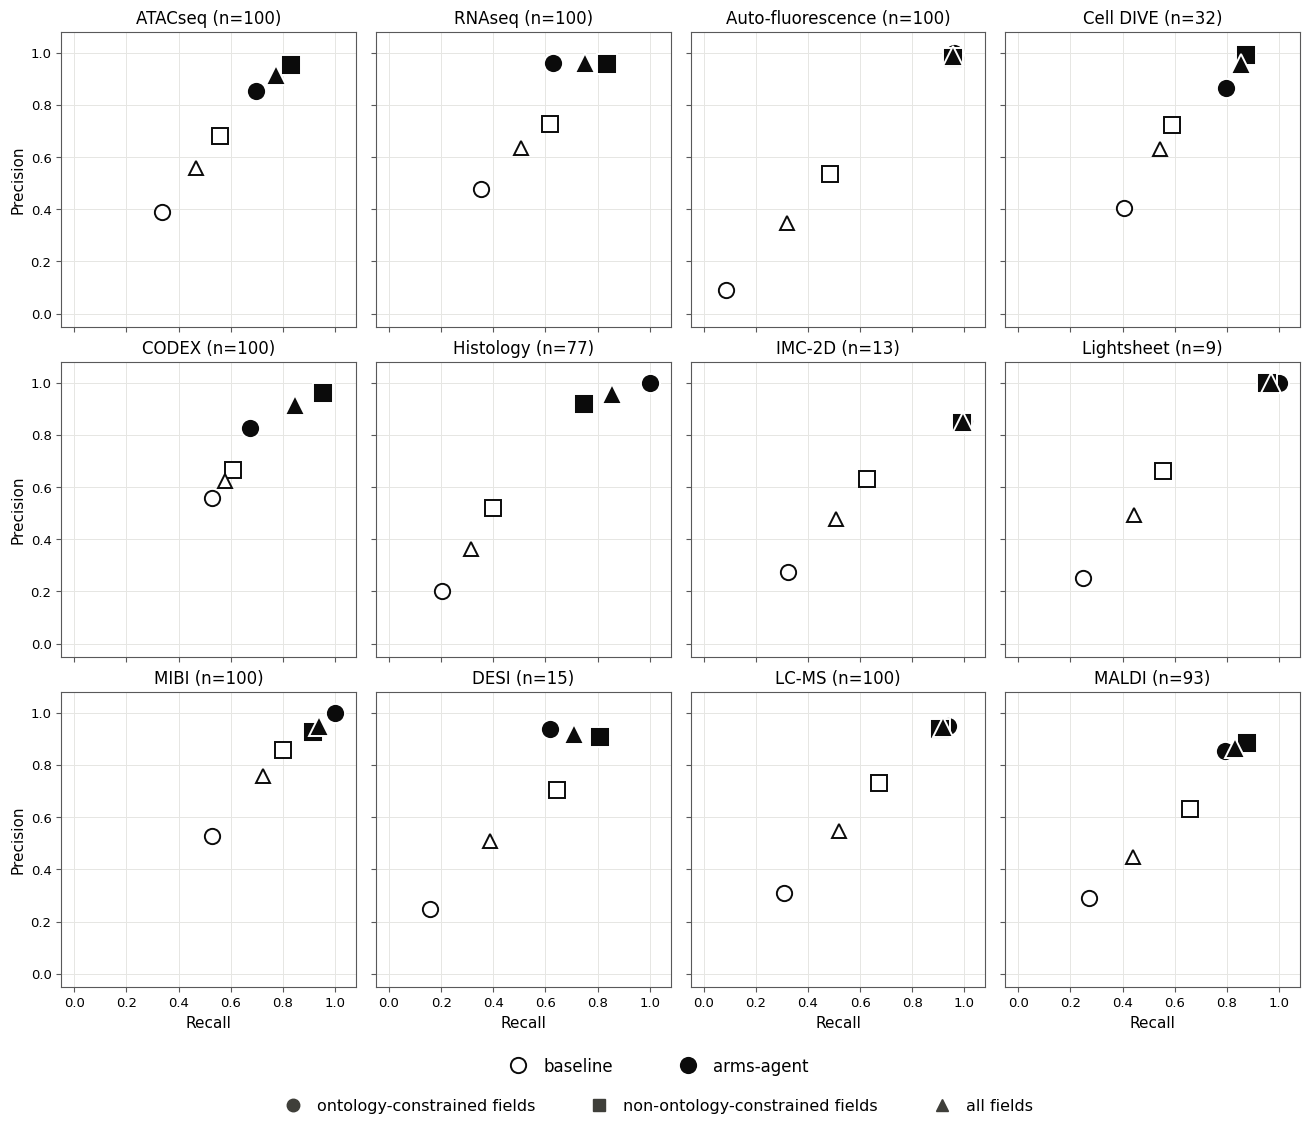

In [11]:
from plots import plot_pr_space

plot_pr_space(
    DATA_ROOT,
    MODEL,
    assays=tuple(ASSAYS),
    baseline_runs=("baseline",),
    system_runs=("arms-agent",),
    field_types=("ontology", "non_ontology", "all"),
    shared_window=True,
    error_axes=False,
    show_f1_contours=False,
    no_color=True,
)

**Some observations run through the panels.**

**Every panel moves the same way.** In all twelve assays, and for all three field categories, the filled markers sit above and to the right of the open ones. No assay and no field category is worse under ARMS.

**Ontology fields travel furthest.** Under the baseline the circle is the lowest and leftmost marker in nearly every panel. Under ARMS that observation is gone and in all the panels the circle now sits at the top rightmost, indicating the vocabulary lookup works well to improve precision and recall.

**Recall is the weak side**. ARMS is accurate about the values it writes, but it writes too few of them. DESI, RNAseq and ATACseq have the widest recall gaps. High precision and high recall serve the curator well. Filling a blank is quick work; catching a wrong value that reads as plausible is not. The error analysis below shows where the blanks come from: two thirds of the distinct errors are deletions, and most of those are values the legacy record carries but ARMS did not copy.

## Error Analysis

Two levels. A **category** is the confusion case, named for what the run did: `substitutions`, `deletions`, `insertions`. Its **sub-categories** split them into specific cases.

| confusion | category | sub-category | description |
|---|---|---|---|
| FP + FN | `substitutions` | `close_match` | Gold has a value, ARMS asserts one that is partly right without being it exactly. |
| FP + FN | `substitutions` | `mislocate_legacy_value` | Gold has a value, ARMS asserts a value the legacy record carries but under a *wrong* field. The instinct to copy was right but the source field was wrong. |
| FP + FN | `substitutions` | `completely_wrong` | Gold has a value, ARMS asserts one that is neither near gold's nor carried anywhere in the legacy record. Nothing in the input accounts for it. |
| FN | `deletions` | `underestimate_legacy_value` | Gold has a value the legacy record carries, ARMS asserts nothing. It was there to be copied and was left behind. |
| FN | `deletions` | `entirely_dont_know` | Gold has a value the legacy record does not carry, ARMS asserts nothing. There was nothing in the input to go on, and ARMS did not make any guess. |
| FP | `insertions` | `overestimate_legacy_value` | Gold leaves the field blank, ARMS asserts a value the legacy record carries. It read more into the legacy record than the curator did. |
| FP | `insertions` | `too_optimistic_answer` | Gold leaves the field blank, ARMS asserts a value of its own, the legacy record carries nothing. The agent answered where it should have abstained. |

In [12]:
import notebook_utils

SYSTEM_RUN = "arms-agent"

errors = notebook_utils.show_error_analysis(DATA_ROOT, MODEL, SYSTEM_RUN, apply_dedup=True)

=== arms-agent: every counted error, categorised ===
  FP: 1078 counted, 1078 categorised -- accounted for
  FN: 2729 counted, 2729 categorised -- accounted for
  deduplicated: 2920 instances of 463 distinct errors, counted once each

--- by category: what the run did (one distinct error is one unit) ---
     category  ATACseq  Auto-fluorescence  CODEX  Cell DIVE  DESI  Histology  IMC-2D  LC-MS  Lightsheet  MALDI  MIBI  RNAseq  total  share
substitutions       20                  2      8          3     5          5       0     21           0     11     4      19     98  0.212
    deletions       64                 14     14         15    11         19       1     27           3     13    22     103    306  0.661
   insertions       15                  0      5          0     0          0       6      2           0      1     0      30     59  0.127

    the same errors, by sub-category:
               subcategory  ATACseq  Auto-fluorescence  CODEX  Cell DIVE  DESI  Histology  IMC-2D  

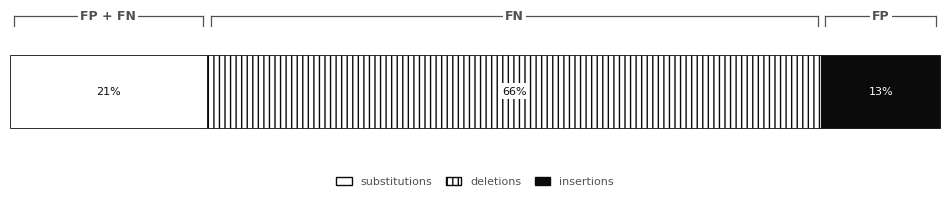

In [13]:
from plots import plot_corpus_error_composition

plot_corpus_error_composition(
    DATA_ROOT,
    MODEL,
    SYSTEM_RUN,
    no_color=True,
    show_subcategories=False,
    show_confusion=True,
    apply_dedup=True,
)